## Requirements

In [38]:
%pip install wfdb --no-deps

Note: you may need to restart the kernel to use updated packages.


## Import and Configuration

In [50]:
# Standard Library
import os
import json
import random
from pathlib import Path

# Data Manipulation & Math
import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Processing & Domain Specific
import wfdb
from scipy.signal import butter, filtfilt

# Scikit-Learn (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, hamming_loss
)

# TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dense, Dropout, SpatialDropout1D,
    Activation,BatchNormalization, Add, GlobalAveragePooling1D, Concatenate,
    Lambda, Reshape, UpSampling1D, Conv1DTranspose, Layer, Cropping1D,
    Bidirectional, LSTM
)

# Configuration & Constants
INPUT_DIR = "/kaggle/input/"
OUTPUT_DIR = "/kaggle/working/"
DATASET_PATH = os.path.join(INPUT_DIR, "datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1")
META_FILE_PTB = os.path.join(DATASET_PATH, "ptbxl_database.csv")
META_FILE_SCP = os.path.join(DATASET_PATH, "scp_statements.csv")

# Research Grade Parameters
SEED = 42
SAMPLE_RATE = 500
AGGREGATE_CLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES = len(AGGREGATE_CLASSES)
MAX_RECORDS = 10000

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Helper Functions

In [40]:
def safe_eval_scp(scp_code):
    """
    Description: Safely converts string-formatted SCP dictionaries into Python dictionary objects.
    Input: str or dict
    Output: dict
    """
    try: 
        return eval(scp_code) if isinstance(scp_code, str) else scp_code
    except: 
        return {}

def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=45.0, order=2):
    """
    Description: Applies a Butterworth bandpass filter to remove baseline wander and noise.
    Input: numpy array, float, float, float, int
    Output: numpy array
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandpass')
    return filtfilt(b, a, signal, axis=0)

def ensure_len(signal, target_len):
    """
    Description: Pads or truncates the signal to reach a consistent target length.
    Input: numpy array, int
    Output: numpy array
    """
    current_len = len(signal)
    if current_len > target_len:
        return signal[:target_len]
    elif current_len < target_len:
        pad_len = target_len - current_len
        return np.pad(signal, ((0, pad_len), (0, 0)), mode='constant')
    return signal

def normalize_dataset(X):
    """
    Description: Applies Lead-wise Z-score Normalization (Research Grade).
                 Standardizes each lead for every patient individually.
    Input: numpy array (records, samples, leads)
    Output: numpy array (records, samples, leads)
    """
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std

def find_optimal_threshold(y_true, y_prob):
    """
    Description: Searches for the threshold that maximizes the F1-Score 
                 for the Binary Screening task on the validation set.
    Input: numpy array (N, 5), numpy array (N, 5)
    Output: float (optimal threshold)
    """
    # Create True Binary Ground Truth (0=NORM only, 1=Any Pathology)
    y_true_bin = np.array([0 if (row[0] == 1 and np.sum(row) == 1) else 1 for row in y_true])
    # Model's max suspicion of ANY pathology
    path_probs = np.max(y_prob[:, 1:], axis=1) 
    
    thresholds = np.linspace(0.01, 0.9, 90)
    f1_scores = [f1_score(y_true_bin, (path_probs > t).astype(int), zero_division=0) for t in thresholds]
    
    opt_t = thresholds[np.argmax(f1_scores)]
    print(f"Optimal Threshold Found: {opt_t:.3f} (Val F1: {max(f1_scores):.4f})")
    return opt_t

def print_result(res):
    """
    Description: Formats and prints classification performance metrics to the console.
    Input: dict [model, accuracy, precision, recall, f1 score]
    """
    print(f"\nModel: {res['model']}")
    print(f"Accuracy: {res['accuracy']:.2%}")
    print(f"Precision: {res['precision']:.2%}")
    print(f"Recall: {res['recall']:.2%}")
    print(f"F1 Score: {res['f1 score']:.2%}")

## Load Metadata

In [57]:
def load_metadata(max_records=MAX_RECORDS):
    """
    Description: Loads PTB-XL CSV files and applies multi-label vectorization 
                 while preserving the research-standard strat_fold.
    Input: int
    Output: pandas DataFrame
    """
    # Load raw dataframes
    ptb_df = pd.read_csv(META_FILE_PTB, index_col='ecg_id')
    scp_df = pd.read_csv(META_FILE_SCP, index_col=0)

    # Convert scp_codes from string to dict
    ptb_df["scp_codes"] = ptb_df["scp_codes"].apply(safe_eval_scp)
    
    # Filter for records with valid filenames (using 100Hz version)
    ptb_df = ptb_df[ptb_df["filename_lr"].notna()] 

    # Build the Dictionary Map (SCP Code -> Diagnostic Class)
    scp_df = scp_df[scp_df["diagnostic_class"].notna()]
    diag_map = scp_df["diagnostic_class"].to_dict()

    # Define Multi-label Vectorization Function
    def get_multilabel_vector(scp_dict):
        vec = np.zeros(len(AGGREGATE_CLASSES), dtype=np.float32)
        for code in scp_dict.keys():
            if code in diag_map:
                cls = diag_map[code]
                if cls in AGGREGATE_CLASSES:
                    vec[AGGREGATE_CLASSES.index(cls)] = 1.0
        return vec

    # Apply Multi-label Vectors
    ptb_df["label_vector"] = ptb_df["scp_codes"].apply(get_multilabel_vector)
    
    # Create Binary Label for Screening (0=Only NORM, 1=Any Pathology)
    ptb_df["label_binary"] = ptb_df["label_vector"].apply(
        lambda v: 0 if (v[0] == 1 and np.sum(v) == 1) else 1
    )

    # Filter out records that don't belong to any of the 5 superclasses
    ptb_df = ptb_df[ptb_df["label_vector"].apply(lambda v: np.sum(v) > 0)]

    # Optional Sampling
    if max_records:
        ptb_df = ptb_df.sample(n=min(max_records, len(ptb_df)), random_state=SEED)

    return ptb_df.reset_index()

ptb_df = load_metadata()
print("Total valid records: ", {len(ptb_df)})
print("\nBinary Counts (0=Normal, 1=Abnormal):")
print(ptb_df["label_binary"].value_counts())
ptb_df[["ecg_id", "scp_codes", "label_vector", "label_binary"]]

Total valid records:  {10000}

Binary Counts (0=Normal, 1=Abnormal):
label_binary
1    5744
0    4256
Name: count, dtype: int64


,ecg_id,scp_codes,label_vector,label_binary
0,3414,"{'NORM': 50.0, 'SR': 0.0}","[1.0, 0.0, 0.0, 0.0, 0.0]",0
1,4761,"{'NST_': 100.0, 'AFIB': 100.0}","[0.0, 0.0, 1.0, 0.0, 0.0]",1
2,2564,"{'NDT': 100.0, 'SR': 0.0}","[0.0, 0.0, 1.0, 0.0, 0.0]",1
3,13929,"{'NORM': 100.0, 'SR': 0.0}","[1.0, 0.0, 0.0, 0.0, 0.0]",0
4,13339,"{'WPW': 100.0, 'SR': 0.0}","[0.0, 0.0, 0.0, 1.0, 0.0]",1
...,...,...,...,...
9995,7013,"{'IMI': 15.0, 'ABQRS': 0.0, 'SR': 0.0}","[0.0, 1.0, 0.0, 0.0, 0.0]",1
9996,1055,"{'ASMI': 15.0, 'LAFB': 100.0, 'STACH': 0.0}","[0.0, 1.0, 0.0, 1.0, 0.0]",1
9997,12437,"{'NDT': 100.0, 'LVH': 15.0, 'LOWT': 0.0, 'STD_...","[0.0, 0.0, 1.0, 0.0, 1.0]",1
9998,20858,"{'IMI': 100.0, 'ABQRS': 0.0, 'SR': 0.0}","[0.0, 1.0, 0.0, 0.0, 0.0]",1


## Load One Signal and Smoke Test

Showing first 1 records (12-Lead view)...


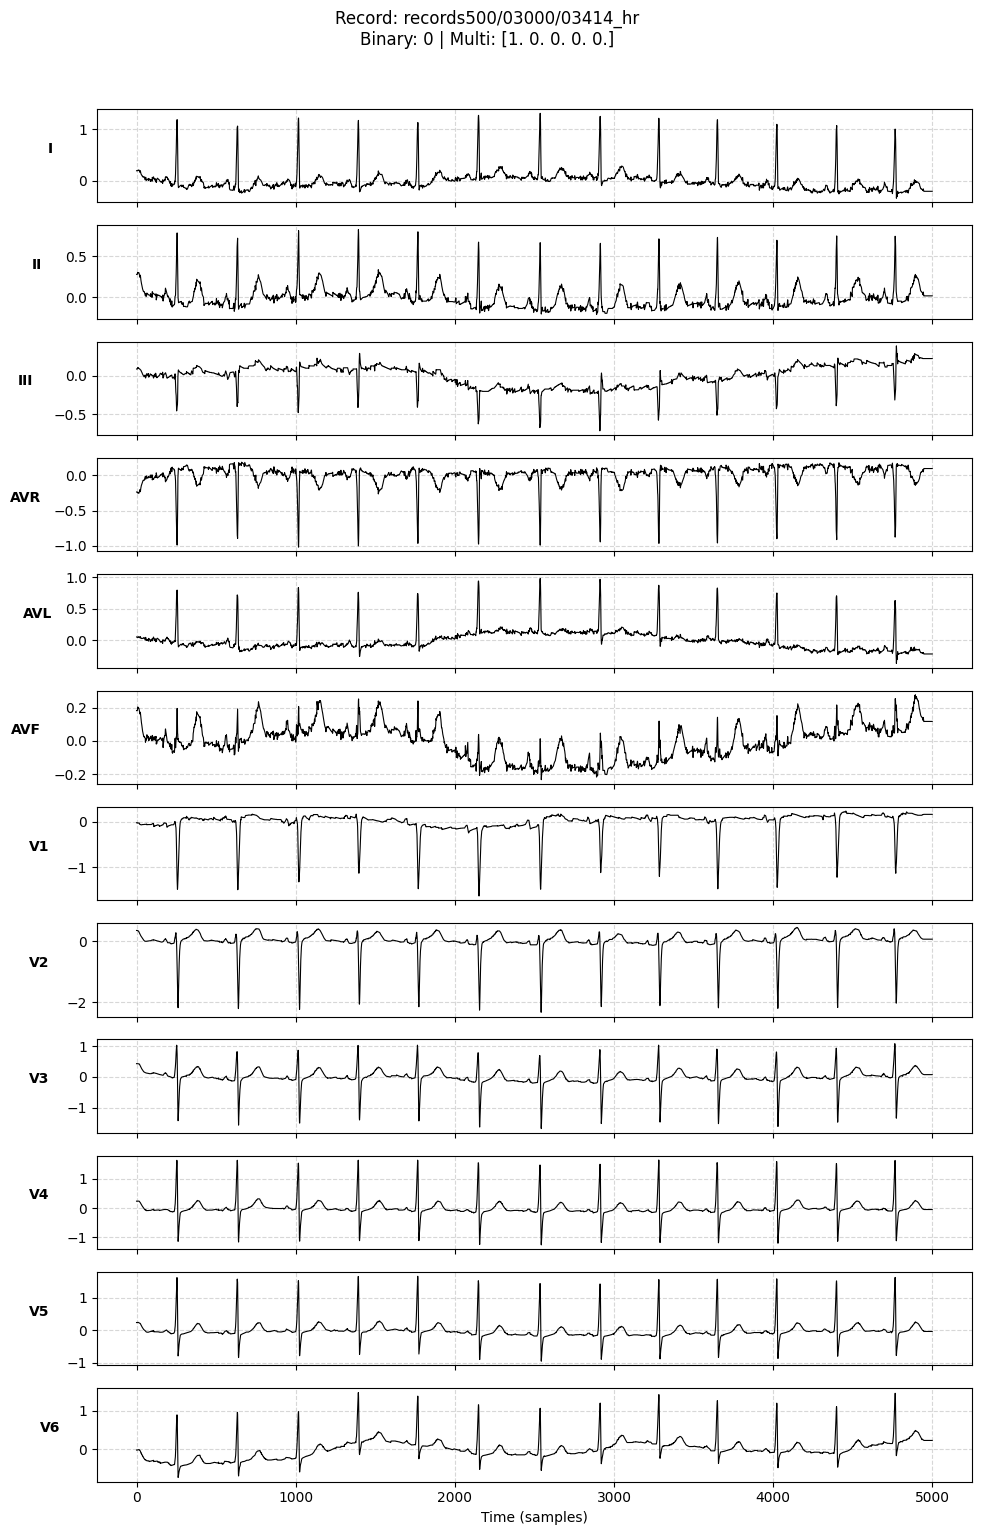

In [59]:
def load_signal_single(filename, base_path=DATASET_PATH):
    """
    Description: Loads a single 12-lead ECG signal using the wfdb library.
    Input: str, str
    Output: numpy array (samples, 12)
    """
    try:
        path = os.path.join(base_path, filename)
        signal, _ = wfdb.rdsamp(path)
        return signal.astype(np.float32)
    except:
        return None

def smoke_test(df, count=1):
    """
    Description: Visualizes the first N records of the provided DataFrame in a 
                 stacked 12-lead anatomical view to verify data integrity.
    Input: pandas DataFrame [filename_lr/filename_hr, label_binary, label_multiclass, ...], int
    """
    print(f"Showing first {count} records (12-Lead view)...")

    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    for row in df.itertuples():
        file = "filename_lr" if SAMPLE_RATE == 100 else "filename_hr"
        sig = load_signal_single(getattr(row, file))
        if sig is None:
            continue

        # Ensure length
        sig = ensure_len(sig, SAMPLE_RATE * 10)

        # Plot all 12 leads stacked
        fig, axes = plt.subplots(12, 1, figsize=(10, 15), sharex=True)

        for i in range(12):
            ax = axes[i]
            ax.plot(sig[:, i], color='black', linewidth=0.8)
            ax.set_ylabel(lead_names[i], rotation=0, labelpad=20, fontsize=10, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.5)
            if i < 11:
                ax.tick_params(labelbottom=False)

        plt.suptitle(f"Record: {getattr(row, file)}\nBinary: {row.label_binary} | Multi: {row.label_vector}", y=1.02)
        plt.xlabel("Time (samples)")
        plt.tight_layout()
        plt.show()

        count -= 1
        if count == 0:
            return

smoke_test(df=ptb_df)

## Build and Split Dataset

In [43]:
def build_dataset(df):
    """
    Description: Iteratively loads signals and aggregates data with fold 
                 assignments using selected frequency filenames.
    Input: pandas DataFrame
    Output: tuple (X, y_bin, y_vec, folds)
    """
    X, y_bin, y_vec, folds = [], [], [], []
    file = "filename_lr" if SAMPLE_RATE == 100 else "filename_hr"

    for row in tqdm(df.itertuples(), total=len(df), desc=f"Loading {SAMPLE_RATE}Hz ECGs"):
        sig = load_signal_single(getattr(row, file)) 
        if sig is None: continue
            
        # Apply Clinical Bandpass Filter
        sig = apply_bandpass_filter(sig, fs=float(SAMPLE_RATE))
        
        # Standardize length to 10 seconds (100 * 10 or 500 * 10)
        sig = ensure_len(sig, SAMPLE_RATE * 10) 

        X.append(sig)
        y_bin.append(row.label_binary)
        y_vec.append(row.label_vector)
        folds.append(row.strat_fold)

    # Stack to create 3D Array: (records, samples, 12)
    X = np.stack(X)
    y_bin = np.array(y_bin)
    y_vec = np.stack(y_vec)
    folds = np.array(folds)
    
    return X, y_bin, y_vec, folds

# Build
X, y_bin, y_vec, folds = build_dataset(ptb_df)

# Normalization
X = normalize_dataset(X)

# Split (1-8: Train, 9: Val, 10: Test)
train_idx = np.where(folds <= 8)[0]
val_idx   = np.where(folds == 9)[0]
test_idx  = np.where(folds == 10)[0]

X_train, y_train = X[train_idx], y_vec[train_idx]
X_val,   y_val   = X[val_idx],   y_vec[val_idx]
X_test,  y_test  = X[test_idx],  y_vec[test_idx]

y_bin_test = y_bin[test_idx]

# Display Shapes 
print("\n--- Final Research Dataset Built ---")
print(f"Total Records: {len(X)}")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}  | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

Loading 500Hz ECGs: 100%|██████████| 10000/10000 [04:01<00:00, 41.49it/s]



--- Final Research Dataset Built ---
Total Records: 10000
X_train shape: (7978, 5000, 12) | y_train shape: (7978, 5)
X_val shape:   (1027, 5000, 12)  | y_val shape:   (1027, 5)
X_test shape:  (995, 5000, 12)  | y_test shape:  (995, 5)


## Universal Evaluator

In [44]:
def evaluate_model(model_name, y_true, y_prob, threshold):
    """
    Description: Calculates standard screening metrics (Acc/Prec/Rec/F1) and 
                 diagnostic benchmarking metrics (Macro-AUC/Per-Class AUC).
    Input: str, numpy array (N, 5), numpy array (N, 5)
    Output: dict [model, accuracy, precision, recall, f1_score, macro_auc, per_class_auc]
    """
    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*60}")

    # Generate multi-label predictions using the array
    y_pred = (y_prob > threshold).astype(int)

    # Derive Binary Screening (Normal vs Abnormal)
    y_true_bin = np.array([0 if (row[0] == 1 and np.sum(row) == 1) else 1 for row in y_true])
    y_pred_bin = np.any(y_pred[:, 1:], axis=1).astype(int)

    # Calculate Standard Binary Metrics
    acc  = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    # Calculate Research Metrics
    macro_auc = roc_auc_score(y_true, y_prob, average='macro')
    
    # Print Screening Report
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Macro-AUC: {macro_auc:.4f}")
    print("-" * 30)
    
    # Print Class-wise Performance
    per_class_auc = {}
    print("Individual Class AUC-ROC:")
    for i, name in enumerate(AGGREGATE_CLASSES):
        score = roc_auc_score(y_true[:, i], y_prob[:, i])
        per_class_auc[name] = score
        print(f" - {name:5}: {score:.4f}")

    # Plot Confusion Matrix (Screening)
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"{model_name} Screening Matrix")
    plt.show()

    # Return exactly as requested
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "macro_auc": macro_auc,
        "per_class_auc": per_class_auc
    }

## CNN Model Building and Training (Binary Classification)

In [55]:
# Configuration
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
EPOCHS = 50
BATCH_SIZE = 32

# Define CNN Architecture
def build_cnn(input_shape=INPUT_SHAPE):
    """
    Description: Constructs a 1D CNN with hierarchical blocks for multi-label 
                 diagnostic classification using Sigmoid output and Macro-AUC.
    Input: tuple (samples, leads)
    Output: keras.Model
    """
    model = Sequential()
    model.add(Input(shape=input_shape))                              # Shape: (32, 1000, 12)

    # Block 1: Low-level features
    model.add(Conv1D(filters=32, kernel_size=32, strides=2, padding='same'))    # Shape: (32, 500, 32)
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Block 2: Mid-level features
    model.add(Conv1D(filters=64, kernel_size=15, strides=2, padding='same'))    # Shape: (32, 250, 64)
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Block 3: High-level features
    model.add(Conv1D(filters=128, kernel_size=11, padding='same'))   # Shape: (32, 250, 128)
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Classifier Head
    model.add(GlobalAveragePooling1D())                              # Shape: (32, 128)
    model.add(Dense(128, activation='relu'))                         # Shape: (32, 128)
    model.add(Dropout(0.5))
    
    # Multi-label Output: 5 nodes with independent probabilities
    model.add(Dense(NUM_CLASSES, activation='sigmoid'))              # Shape: (32, 5)

    # Compile with Research Gold Standard (Macro-AUC)
    optimizer = Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model

# Build the model
print(f"\n{'='*40}")
print("BUILDING RESEARCH CNN")
print(f"{'='*40}")
cnn = build_cnn()
cnn.summary()

# Train using the Splits (Folds 1-8 for train, 9 for val)
callbacks_cnn = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
]

history_cnn = cnn.fit(
    X_train, y_train,        # Folds 1-8
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

# Save the model
cnn.save(os.path.join(OUTPUT_DIR, 'cnn_model.keras'))


BUILDING RESEARCH CNN


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_313 (Conv1D)             │ (None, 2500, 32)       │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_344         │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_245 (Activation)     │ (None, 2500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_314 (Conv1D)             │ (None, 1250, 64)       │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_345         │ (None, 1250, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_246 (Activation)     │ (None, 1250, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_315 (Conv1D)             │ (None, 1250, 128)      │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_346         │ (None, 1250, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_247 (Activation)     │ (None, 1250, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,397 (591.39 KB)

 Trainable params: 150,949 (589.64 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - auc: 0.7752 - loss: 0.4358 - val_auc: 0.8562 - val_loss: 0.4601 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - auc: 0.8564 - loss: 0.3517 - val_auc: 0.8731 - val_loss: 0.4498 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.8721 - loss: 0.3301 - val_auc: 0.8754 - val_loss: 0.3707 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.8775 - loss: 0.3234 - val_auc: 0.8810 - val_loss: 0.3774 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.8818 - loss: 0.3163 - val_auc: 0.8858 - val_loss: 0.3940 - learning_rate: 0.0010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.8856 - loss: 0.3121 - val_auc: 0.8874 - val_loss: 0.3805 - learning_rate: 0.0010
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.8926 - loss: 0.3041 - val_auc: 0.8888 - val_loss: 0.3958 - learning_rate: 0.001

##  CNN Model Evaluation (Binary Classification)

Generating Probabilities...

Tuning threshold on Validation Set...
Optimal Threshold Found: 0.290 (Val F1: 0.8861)

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: 1D CNN
Accuracy:  0.8693
Precision: 0.8938
Recall:    0.8714
F1 Score:  0.8825
Macro-AUC: 0.9094
------------------------------
Individual Class AUC-ROC:
 - NORM : 0.9395
 - MI   : 0.9205
 - STTC : 0.9345
 - CD   : 0.9102
 - HYP  : 0.8424


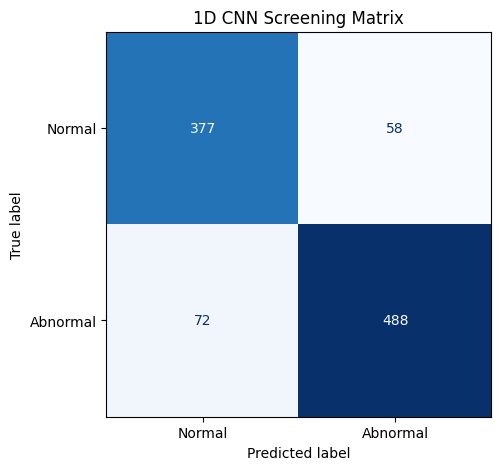

In [56]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_prob_val = cnn.predict(X_val, verbose=0)
y_prob_test = cnn.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_threshold = find_optimal_threshold(y_val, y_prob_val)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_cnn = evaluate_model("1D CNN", y_test, y_prob_test, opt_threshold)

## AG-ResNET Model Building and Training (Binary Classification)

In [53]:
# Configuration
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
NUM_CLASSES = 5
NUM_BLOCKS = 3
FILTERS_START = 32

LEARNING_RATE = 0.0005 
BATCH_SIZE = 16
EPOCHS = 50

# Define Residual Block Architecture
def residual_block(x, filters, kernel_size=10, stride=1):
    """
    Description: Implements a standard 1D Residual bottleneck with 'swish' activation and 
                 spatial dropout; includes a 1x1 convolution shortcut if dimensions change.
    Input: tensorflow.Tensor [time, channels], int, int, int
    Output: tensorflow.Tensor [time/stride, filters]
    """

    shortcut = x

    # Path A
    x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = SpatialDropout1D(0.2)(x)

    x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Path B
    if x.shape[-1] != shortcut.shape[-1] or stride != 1:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('swish')(x)
    return x

# Define AG ResNet Architecture
def build_ag_resnet(input_shape=INPUT_SHAPE):
    """
    Description: Constructs the Anatomically Grouped ResNet by splitting 12 leads into 
                 5 regional branches (Septal, Anterior, Lateral, Inferior, Posterior) before 
                 fusing them for classification.
    Note: samples = signal duration * frequency
    Input: tuple (samples, leads)
    Output: keras.src.models.model.Model
    """
    # --- BLOCK 1: INPUT & TRIAGE ---
    input_layer = Input(shape=input_shape, name="ecg_input") # Shape: (16, 5000, 12)
 
    septal = Lambda(lambda x: __import__('tensorflow').gather(x, [6, 7], axis=2), name="Septal")(input_layer)            # Shape: (16, 5000, 2)
    anterior = Lambda(lambda x: __import__('tensorflow').gather(x, [8, 9], axis=2), name="Anterior")(input_layer)        # Shape: (16, 5000, 2)
    lateral = Lambda(lambda x: __import__('tensorflow').gather(x, [0, 4, 10, 11], axis=2), name="Lateral")(input_layer)  # Shape: (16, 5000, 4)
    inferior = Lambda(lambda x: __import__('tensorflow').gather(x, [1, 2, 5], axis=2), name="Inferior")(input_layer)     # Shape: (16, 5000, 3)
    posterior = Lambda(lambda x: __import__('tensorflow').gather(x, [3], axis=2), name="Posterior")(input_layer)         # Shape: (16, 5000, 1)

    # --- BLOCK 2: ENCODER ---
    branches = []

    for name, branch in zip(["Global", "Septal", "Anterior", "Lateral", "Inferior", "Posterior"],
                            [input_layer, septal, anterior, lateral, inferior, posterior]):

        # Initial Feature Extraction
        x = Conv1D(FILTERS_START, 32, strides=2, padding='same', name=f"{name}_Conv1")(branch) # Shape: (16, 2500, 64)
        x = BatchNormalization()(x)                                                                   # Shape: (16, 2500, 64)
        x = Activation('swish')(x)                                                                    # Shape: (16, 2500, 64)

        # Dynamic Residual Stacking
        current_filters = FILTERS_START * 2
        for i in range(NUM_BLOCKS):
            x = residual_block(x, current_filters, stride=2) # Shape: (16, 1250, 128) -> (16, 625, 256) -> (16, 313, 512) -> (16, 157, 1024)
            if i < 1: current_filters *= 2

        x = GlobalAveragePooling1D(name=f"{name}_GlobalPool")(x) # Shape: (16, 1024)
        branches.append(x)                                              # Shape: (16, 6, 1024)

    # --- BLOCK 3: FUSION ---
    m = Concatenate(name="Anatomical_Fusion")(branches) # Shape: (16, 6 * 1024)
    m = Reshape((len(branches), -1))(m) 
    m = Bidirectional(LSTM(128, return_sequences=False))(m)

    # --- BLOCK 4: CLASSIFICATION HEAD ---
    c = BatchNormalization()(m)                         # Shape: (16, 5120)
    c = Dense(256, activation='swish')(c)                    # Shape: (16, 128)
    c = Dropout(0.4)(c)                                      # Shape: (16, 128)
    
    output_layer = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)  # Shape: (16, 1)

    # --- BLOCK 5: COMPILATION (Pure Classification) ---
    model = Model(inputs=input_layer, outputs=output_layer, name="AG_ResNet")

    # Added clipnorm=1.0 to prevent gradient explosions
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), 
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )

    return model

# Build
print(f"{'='*50}")
print(f"AG-ResNet TRAINING (PURE CLASSIFIER)")
print(f"Input: {INPUT_SHAPE}")
print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
print(f"{'='*50}")

ag_resnet = build_ag_resnet()

# Train
callbacks_ag_resnet = [
    ReduceLROnPlateau(
        monitor='val_auc', factor=0.2, 
        patience=5, min_lr=1e-5, verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', mode='max', patience=12, 
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "ag_resnet_multilabel.keras"), 
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    )
]

print("\nStarting Training...")
history_ag_resnet = ag_resnet.fit(
    x=X_train,              # Folds 1-8
    y=y_train,              # Multi-label vectors [NORM, MI, STTC, CD, HYP]
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ag_resnet,
    verbose=1
)

AG-ResNet TRAINING (PURE CLASSIFIER)
Input: (5000, 12)
Structure: 3 Blocks | Start Filters: 32

Starting Training...
Epoch 1/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - auc: 0.7943 - loss: 0.4414
Epoch 1: val_auc improved from -inf to 0.86816, saving model to /kaggle/working/ag_resnet_multilabel.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 137s 163ms/step - auc: 0.7943 - loss: 0.4413 - val_auc: 0.8682 - val_loss: 0.3859 - learning_rate: 5.0000e-04
Epoch 2/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - auc: 0.8608 - loss: 0.3483
Epoch 2: val_auc improved from 0.86816 to 0.87662, saving model to /kaggle/working/ag_resnet_multilabel.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 77s 154ms/step - auc: 0.8608 - loss: 0.3482 - val_auc: 0.8766 - val_loss: 0.3482 - learning_rate: 5.0000e-04
Epoch 3/50
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - auc: 0.8764 - loss: 0.3287
Epoch 3: val_auc improved from 0.87662 to 0.88886, saving model to /kaggle/working/ag_resnet_multilabel.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 7

## AG-ResNET Model Evaluation (Binary Classification)

Generating Probabilities...

Tuning threshold on Validation Set...
Optimal Threshold Found: 0.290 (Val F1: 0.8898)

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: AG-ResNet
Accuracy:  0.8693
Precision: 0.9103
Recall:    0.8518
F1 Score:  0.8801
Macro-AUC: 0.9190
------------------------------
Individual Class AUC-ROC:
 - NORM : 0.9457
 - MI   : 0.9238
 - STTC : 0.9414
 - CD   : 0.9275
 - HYP  : 0.8565


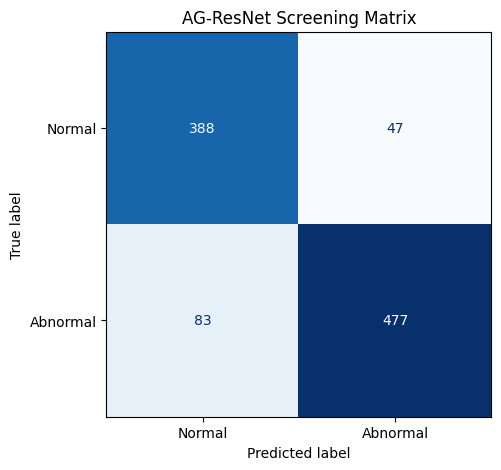

In [54]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_prob_val = ag_resnet.predict(X_val, verbose=0)
y_prob_test = ag_resnet.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_threshold = find_optimal_threshold(y_val, y_prob_val)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_ag_resnet = evaluate_model("AG-ResNet", y_test, y_prob_test, opt_threshold)